In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
import sys
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR')
sys.path.append('/SAN/colcc/Hormad1/projects/MINOTAUR/tiler')

import glob
import warnings
warnings.filterwarnings("ignore")
from typing import Optional, Dict, Any, Tuple

import torch
import seaborn as sns
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import RichProgressBar
from sklearn.preprocessing import LabelEncoder
from scipy.special import expit
from sklearn.metrics import accuracy_score, auc, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

from arg_def_cat import Args
from loader.tile_loader import TileDataset, MultinominalSampler
from cem_mil.models.cem_mil import ConceptEmbeddingModel
import cem_mil.train.utils as utils

['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/home/verghese/.local/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages', '/SAN/colcc/Hormad1/projects/MINOTAUR', '/SAN/colcc/Hormad1/projects/MINOTAUR/tiler', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor', '/tmp/5511444.1.gpu.q/tmpr6ipp806']


In [3]:
CONCEPTS = ['Stage', 'Age', 'Cancer'] 

In [4]:
pcanc_train_cohort = pd.read_csv('/SAN/colcc/Hormad1/data/datasets/cat_stcanage_60surv_train_cohort.csv')

In [5]:
pcanc_train_cohort['ID']

0       TCGA-FB-AAQ1
1       TCGA-DM-A28K
2       TCGA-44-7669
3       TCGA-KL-8328
4       TCGA-CV-7263
            ...     
1644    TCGA-LL-A73Z
1645    TCGA-GM-A2DK
1646    TCGA-AA-3989
1647    TCGA-CV-5973
1648    TCGA-33-4538
Name: ID, Length: 1649, dtype: object

In [6]:
pcanc_train_cohort['stratify_col'] = pcanc_train_cohort[CONCEPTS[:2]].astype(str).agg('-'.join, axis=1)

train_df, val_df = train_test_split(
    pcanc_train_cohort, 
    test_size=0.2, 
    stratify=pcanc_train_cohort['stratify_col'], 
    random_state=42
)

train, val = list(train_df['ID']), list(val_df['ID'])
pcanc_train_cohort['test'] = pcanc_train_cohort['ID'].apply(lambda x: 1 if x in train else 0)

In [7]:
value_counts = pcanc_train_cohort['Cancer'].value_counts().sort_index()

In [8]:
def get_concept_weights(cohort):
    
    col_weights_dic = {}
    for column in CONCEPTS:
        value_counts = cohort[column].value_counts().sort_index()
        total_counts = sum(value_counts)
        weights = {cls: total_counts/(len(value_counts)*v) for cls, v in value_counts.items()}
        col_weights_dic[column]=weights

    cpt_class_weights = [v2 for k, v in col_weights_dic.items() for k2, v2 in v.items()]
    
    return cpt_class_weights 

In [9]:
cpt_class_weights=get_concept_weights(pcanc_train_cohort)

In [10]:
cpt_class_weights = [1.0]*len(cpt_class_weights)
#plt.bar(list(k for k, _ in col_weights_dic.items()), cpt_class_weights)
#plt.xticks(rotation=90)

### DataLoaders

In [30]:
#DB_PATH = '/SAN/colcc/Hormad1/data/embeddings/uni/224-20x-0.2'
DB_PATH = '/SAN/colcc/Hormad1/data/embeddings/vi/224-20x-0.2'
#db_path = '/Users/k2030634/PhD/Isambard/data/features'

In [31]:
def get_dloaders(
        train_data,
        val_data,
        args: Any,
        ) -> Tuple[Optional[DataLoader], Optional[DataLoader]]:
        """
        Sets up the data loaders for training and validation.

        Args:
            args: Namespace, model arguments.
            with_data: Boolean, if True loads data.

        Returns:
            Tuple[DataLoader, DataLoader]: Train and validation data loaders.
        """
        db_paths = glob.glob(
            os.path.join(DB_PATH, 'features', '*')
            #os.path.join(db_path, '*')
        )
        #print('gregggg',db_paths)
        #need to get correct number of dbs for weights
        #TODO remove from tileloader.py
        train_dbs = [
            p 
            for p in db_paths 
            for db in list(train_data['ID']) 
            if db==os.path.basename(p[:-4])
            ]

        print(len(train_dbs))
        
        train_weights = [1 for i in range(len(train_dbs))]
        
        mn_sampler = MultinominalSampler(
            train_weights, 
            len(train_dbs)
            )
        
        train_dataset = TileDataset(train_data, args.db_path, args.target, args.cpt_ids, args.bag_n)
        val_dataset = TileDataset(val_data, args.db_path, args.target, args.cpt_ids, args.bag_n)

        #increase num of workers if not local
        train_dloader = DataLoader(
            train_dataset, 
            args.batch_size, 
            sampler = mn_sampler, 
            num_workers = 36,
            drop_last=True
            )

        #increase num of workers if not local
        val_dloader = DataLoader(
            val_dataset, 
            batch_size=4, 
            num_workers = 36)

        return train_dloader, val_dloader

In [32]:
os.cpu_count()

40

In [33]:
args = Args(DB_PATH)
train_data = pcanc_train_cohort[pcanc_train_cohort['test']==1]
val_data = pcanc_train_cohort[pcanc_train_cohort['test']==0]
train_dloader, val_dloader = get_dloaders(train_data=train_data,val_data=val_data,args=args)

100
greg 40
Loading 39%num bags 40
greg 40
Loading 39%num bags 40


In [34]:


args.batch_size

64

class Args():
    def __init__(
        self,
        table_data,
        db_path = '../data/features',
        bag_n = 200,
        database = 'lmdb',
        target = 'Survival',
        sampler = 'random',
        val_sampler = 'random',
        use_val = False,
        batch_size = 32,
        sample_wr_whole_label = 0,
        no_strat_sampling = 1
        ):
        
        self.db_path = db_path
        self.table_data = table_data
        self.bag_n = bag_n
        self.database = database
        self.target = target
        self.sampler = sampler
        self.val_sampler = val_sampler
        self.use_val = use_val
        self.batch_size = batch_size
        self.sample_wr_whole_label = sample_wr_whole_label
        self.no_strat_sampling = no_strat_sampling

### Training

In [35]:
LOGS_PATH = '/SAN/colcc/Hormad1/analysis/minotaur/logs/job/'
OUT_PATH = '/SAN/colcc/Hormad1/analysis/minotaur/'
logger1 = TensorBoardLogger(LOGS_PATH, name='categorical_test2')

In [36]:
N_CONCEPTS = 3
CONCEPT_STATES = [4, 3, 10]
N_TASKS = 1
H_DIM = 1536
EMB_SIZE = 8
PRE_BN_ML = True
ACT = "LeakyReLU"

In [37]:
#attention callback to log attention
attention_hook = utils.AttentionHook()
atten_callback = utils.SaveAttentionCallback(
    attention_hook=attention_hook
)

cem_model = ConceptEmbeddingModel(
    n_concepts=N_CONCEPTS, 
    concept_states=CONCEPT_STATES,
    n_tasks=N_TASKS, 
    h_dim=H_DIM,
    pre_bn_mlp=PRE_BN_ML,
    emb_size=EMB_SIZE,
    embedding_activation=ACT,
    concept_loss_weight=10,
    concept_class_weights=torch.tensor(cpt_class_weights).float(),
    learning_rate=1e-3,  
    dropout=0.3,
    optimizer="adam",  
    attention_hook=attention_hook
)

weights tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
c2y model Sequential(
  (0): Linear(in_features=24, out_features=1, bias=True)
)
concept weights 17


In [38]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices="auto", 
    max_epochs=30,
    check_val_every_n_epoch=30,
    callbacks = [atten_callback], #RichProgressBar()
    enable_progress_bar=True,
    logger=logger1
)

trainer.fit(cem_model, train_dloader, val_dloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                       | Type              | Params | Mode 
-------------------------------------------------------------------------
0 | attention_blocks           | ModuleList        | 1.2 M  | train
1 | bn                         | BatchNorm1d       | 3.1 K  | train
2 | pre_mlp                    | PreMLP            | 1.5 M  | train
3 | concept_context_generators | ModuleList        | 249 K  | train
4 | concept_prob_generators    | ModuleList        | 1.0 K  | train
5 | c2y_model                  | Sequential        | 25     | train
6 | sig                        | Sigmoid           | 0      | train
7 | loss_task                  | BCEWithLogitsLoss | 0      | train
-------------------------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]Dataset length: 40
Dataset length: 40
Dataset length: 40
Dataset length: 40
Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]                             Dataset length: 40


IndexError: Caught IndexError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/opt/conda/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/SAN/colcc/Hormad1/projects/MINOTAUR/loader/tile_loader.py", line 124, in __getitem__
    wsi_id, bag, target, cpts = self.bags[index]
IndexError: list index out of range


In [ ]:
from sklearn.metrics import accuracy_score, auc, f1_score

x_test, y_test, c_test = [], [], []
for (x, y, c) in val_dloader:
    x_test.append(x)
    y_test.append(y)
    c_test.append(c)
x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
c_test = np.concatenate(c_test, axis=0)


trainer_pred = pl.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=False, # No logs to be dumped for this trainer
)

batch_results = trainer_pred.predict(cem_model, val_dloader)

In [ ]:
#y_probs = np.concatenate(
#    list(map(lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), batch_results)),
#    axis=0,
#)
#batch_results = trainer_pred.predict(cem_model, val_dloader)
#for b in batch_results:
    #print(b[2])
    

In [ ]:
def get_cptprobs(results):
    c_probs = np.concatenate(
        list(map(lambda x: torch.nn.functional.softmax(x[0], dim=-1).detach().cpu().numpy(), results)),
        axis=0,
    )
    return c_probs

In [ ]:
def get_yprobs(results):
    y_probs = np.concatenate(
        list(map(lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), results)),
        axis=0,
    )
    return y_probs

In [ ]:
def get_cembs():
    c_embs = np.concatenate(
        list(map(lambda x: x[1].detach().cpu().numpy(), batch_results)),
        axis=0,
    )
    # Reshape (batch_size, k, emb_size)
    c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))
    return cembs

In [47]:
y_probs = get_yprobs(batch_results)

In [48]:
task_accuracy = accuracy_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

f1 = f1_score(y_test, y_probs >=0.5)
print(f"Our CEM's test task f1 is {f1*100:.2f}%")

Our CEM's test task accuracy is 64.63%
Our CEM's test task f1 is 74.89%


In [54]:
def get_concept_metrics(c_probs):
    c_f1s, c_accs, idx = [], [], 0
    c_pred_lst = []
    for i, n in enumerate(concept_states):
        n_idx = idx+n
        c_probs_states = c_probs[:,idx:n_idx]
        c_pred = np.argmax(c_probs_states, axis=-1)
        c_pred_lst.append(c_pred)
        c = c_test[:, i]
        
        c_accs.append(accuracy_score(c_pred, c))
        c_f1s.append(f1_score(
            c,
            c_pred,
            average='weighted',
        ))

        idx = n_idx

    return c_f1s, c_accs, c_f1s, c_pred_lst

In [55]:
concept_states = [4, 3, 10] 
c_probs = get_cptprobs(batch_results)
c_avg_f1, c_avg_accuracy, c_avg_roc_auc, c_pred_lst = get_concept_metrics(c_probs)
c_avg_f1, c_avg_accuracy, c_avg_roc_auc

In [ ]:
c_avg_f1 = np.mean(c_f1s)
c_avg_accuracy = np.mean(c_accs)
c_avg_roc_auc = np.mean(c_f1s)
c_f1s

In [63]:
c_true = c_test[:,2]
cm = confusion_matrix(c_true, c_pred_lst[2])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print('f1: ',c_avg_f1, 'c acc:', c_avg_accuracy, 'c roc_auc:', c_avg_roc_auc)
print('f1: ',c_f1s, 'c acc:', c_accuracies, 'c roc_auc:', c_f1s)

In [ ]:
def _compute_target_metrics(y_true, y_probs):

    y_probs = torch.nn.Softmax(dim=-1)(y_probs).cpu().detach()
    y_pred = y_probs.argmax(dim=-1).cpu().detach()
    y_true = y_true
    y_accuracy = accuracy_score(y_true, y_pred)
    y_f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
    )
   
    return (y_accuracy, y_f1, y_f1)

_compute_target_metrics(y_test, y_probs)

In [35]:
from cem_mil.models.cem_mil import ConceptEmbeddingModel 

In [36]:
checkpoint_path = "model_checkpoint.ckpt"
#trainer.save_checkpoint(checkpoint_path)

In [37]:
loaded_model = ConceptEmbeddingModel.load_from_checkpoint(
    checkpoint_path,  
    n_concepts=3, 
    concept_states = [10, 4, 4],
    n_tasks=1, 
    h_dim = 1024
)

units [48, 1]


In [ ]:
attention_scores = attention_hook.attention_scores['train']

In [102]:
def plot_attention_density_for_final_epoch(attention_scores, num_batches, num_concepts):
    """
    Plots density plots of attention scores for every tile in the final epoch for each concept.
    """
    softmax = torch.nn.Softmax(dim=-1)
    final_epoch_attention = {concept: [] for concept in range(num_concepts)}

    for concept in range(num_concepts):
        for batch in attention_scores[-num_batches:]:
            batch_tile_scores = torch.stack([score.mean(dim=-1) for score in batch[concept]])
            final_epoch_attention[concept].append(batch_tile_scores)

     
        final_epoch_attention[concept] = torch.cat(final_epoch_attention[concept], dim=0)
        final_epoch_attention[concept] = final_epoch_attention[concept].flatten()
        final_epoch_attention[concept] = softmax(final_epoch_attention[concept]).cpu().numpy()
        
    plt.figure(figsize=(8, 6))
    for concept, attention_data in final_epoch_attention.items():
        sns.kdeplot(attention_data, fill=True, bw_adjust=0.5)
    plt.title(f"Attention Density Plot for Concepts")
    plt.xlabel("Attention Score")
    plt.show()


In [25]:
x_test, y_test, c_test = [], [], []
for (x, y, c) in val_dloader:
    x_test.append(x)
    y_test.append(y)
    c_test.append(c)
x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
c_test = np.concatenate(c_test, axis=0)


In [27]:
trainer = pl.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=False, # No logs to be dumped for this trainer
)
batch_results = trainer.predict(cem_model, val_dloader)

#join over the batch dimension
c_probs = np.concatenate(
    list(map(lambda x: torch.nn.functional.softmax(x[0], dim=-1).detach().cpu().numpy(), batch_results)),
    axis=0,
)

y_pred = np.concatenate(
    list(map(lambda x: torch.nn.Sigmoid()(x[2]).detach().cpu().numpy(), batch_results)),
    axis=0,
)

c_embs = np.concatenate(
    list(map(lambda x: x[1].detach().cpu().numpy(), batch_results)),
    axis=0,
)
# Reshape them so that we have embeddings (batch_size, k, emb_size)
c_embs = np.reshape(c_embs, (c_test.shape[0], c_test.shape[1], -1))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [28]:
##########
## Compute test task accuracy
##########

from scipy.special import expit
from sklearn.metrics import accuracy_score, auc, f1_score

# Which allows us to compute the task accuracy (we explicitly perform a
# sigmoidal operation as CEMs always return logits)
task_accuracy = accuracy_score(y_test, expit(y_pred) >=0.5)
print(f"Our CEM's test task accuracy is {task_accuracy*100:.2f}%")

Our CEM's test task accuracy is 13.11%


In [30]:
concept_states = [10, 4, 4]

In [31]:
idx = 0
c_f1s, c_accuracies, idx = [], [], 0
for i, n in enumerate(concept_states):
    n_idx = idx+n
    c_probs_states = c_probs[:,idx:n_idx]
    c_pred = np.argmax(c_probs_states, axis=-1)
    c = c_test[:, i]
  
    c_accuracies.append(
        accuracy_score(c_pred, c)
        )

    c_f1s.append(f1_score(
        c,
        c_pred,
        average='macro',
    ))

    idx = n_idx

c_avg_f1 = np.mean(c_f1s)
c_avg_accuracy = np.mean(c_accuracies)
c_avg_roc_auc = np.mean(c_f1s)

print('f1: ',c_avg_f1, 'c acc:', c_avg_accuracy, 'c roc_auc:', c_avg_roc_auc)

f1:  0.14033927072309596 c acc: 0.18760640108954715 c roc_auc: 0.14033927072309596


shape1 26050
shape2 torch.Size([104200, 20])
max scores 1.3096505e-06
shape1 26050
shape2 torch.Size([104200, 20])
max scores 1.1691908e-06
shape1 26050
shape2 torch.Size([104200, 20])
max scores 1.2883138e-06


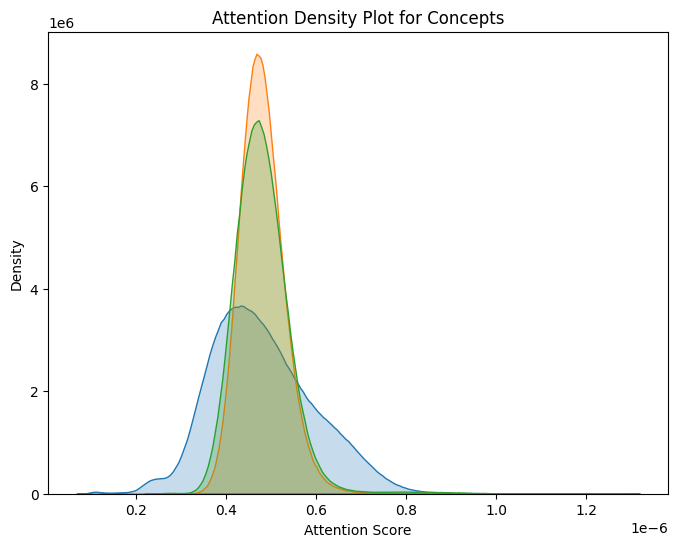

In [105]:
plot_attention_density_for_final_epoch(
    attention_scores=attention_hook.attention_scores['train'],
    num_batches=26050,
    num_concepts=3
)

### Old code

In [86]:
def aggregate_attention_per_concept_with_softmax(attention_scores):
    """
    Aggregates attention scores to compute a single score per concept for each batch,
    then applies softmax normalization across concepts.

    Args:
        attention_scores (list of lists of tensors): 
            Nested list where each element corresponds to [batch][concept][num_tiles, num_heads].

    Returns:
        list of tensors: Aggregated and normalized attention scores with shape [batch][num_concepts].
    """
    softmax = torch.nn.Softmax(dim=-1)  # Softmax along concepts
    aggregated_scores = []

    for batch in attention_scores:
        batch_scores = []
        for score in batch:  # `score` has shape [num_tiles, num_heads]
            # Aggregate across num_heads (last dimension)
            print(score.shape)
            tile_scores = score.mean(dim=-1)  # Shape: [num_tiles]
            # Aggregate across tiles to get a single score for the concept
            concept_score = tile_scores.mean().item()
            batch_scores.append(concept_score)
        batch_scores = torch.tensor(batch_scores)  # Shape: [num_concepts]
        # Apply softmax normalization across concepts
        normalized_scores = softmax(batch_scores)
        print(normalized_scores)
        aggregated_scores.append(normalized_scores)
    
    return aggregated_scores  # List of tensors, each with shape [num_concepts]





def aggregate_attention_by_epoch_with_softmax(aggregated_scores, num_batches, num_epochs):
    """
    Aggregates attention scores into epoch-level averages for each concept.

    Args:
        aggregated_scores (list of tensors): List of tensors with shape [batch][num_concepts].
        num_batches (int): Number of batches per epoch.
        num_epochs (int): Total number of epochs.

    Returns:
        torch.Tensor: Epoch-level attention scores with shape [num_epochs, num_concepts].
    """
    epoch_means = []
    for epoch in range(num_epochs):
        epoch_scores = aggregated_scores[epoch * num_batches : (epoch + 1) * num_batches]
        # Average scores across all batches in the epoch for each concept
        epoch_mean = torch.stack(epoch_scores).mean(dim=0)
        epoch_means.append(epoch_mean)
    return torch.stack(epoch_means)  # Shape: [num_epochs, num_concepts]


import matplotlib.pyplot as plt

def plot_attention_over_epochs(epoch_means, num_epochs, num_concepts):
    """
    Plots the attention scores over epochs for each concept.

    Args:
        epoch_means (torch.Tensor): Tensor of epoch-level attention scores with shape [num_epochs, num_concepts].
        num_epochs (int): Number of epochs.
        num_concepts (int): Number of concepts.
    """
    for concept in range(num_concepts):
        plt.plot(range(1, num_epochs + 1), epoch_means[:, concept].cpu().numpy(), label=f'Concept {concept + 1}')
    
    plt.title('Attention Scores Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Attention Score')
    plt.legend()
    plt.show()




# Step 1: Aggregate per batch with softmax normalization
aggregated_scores = aggregate_attention_per_concept_with_softmax(attention_hook.attention_scores['train'])


# Step 2: Aggregate per epoch
num_batches = 83  # Number of batches per epoch
num_epochs = 100    # Total number of epochs
epoch_means = aggregate_attention_by_epoch_with_softmax(aggregated_scores, num_batches, num_epochs)

# Step 3: Plot the attention scores
num_concepts = epoch_means.shape[1]
plot_attention_over_epochs(epoch_means, num_epochs, num_concepts)




def aggregate_attention_per_embedding(attention_scores):
    """
    Aggregates attention scores to compute an embedding-level score per concept for each batch.

    Args:
        attention_scores (list of lists of tensors): 
            Nested list where each element corresponds to [batch][concept][num_tiles, num_heads].

    Returns:
        list of tensors: Aggregated attention scores with shape [batch][num_concepts, embedding_dim].
    """
    aggregated_scores = []

    for batch in attention_scores:
        batch_scores = []
        for score in batch:  # `score` has shape [num_tiles, num_heads]
            # Aggregate across num_heads
            embedding_scores = score.mean(dim=-1)  # Shape: [num_tiles, embedding_dim]
            # Aggregate across num_tiles to retain embedding-level detail
            concept_embedding_scores = embedding_scores.mean(dim=0)  # Shape: [embedding_dim]
            batch_scores.append(concept_embedding_scores)
        aggregated_scores.append(torch.stack(batch_scores))  # Shape: [num_concepts, embedding_dim]
    
    return aggregated_scores  # List of tensors, each with shape [num_concepts, embedding_dim]



def aggregate_attention_by_epoch_per_embedding(aggregated_scores, num_batches, num_epochs):
    """
    Aggregates attention scores into epoch-level averages for each embedding and concept.

    Args:
        aggregated_scores (list of tensors): List of tensors with shape [batch][num_concepts, embedding_dim].
        num_batches (int): Number of batches per epoch.
        num_epochs (int): Total number of epochs.

    Returns:
        torch.Tensor: Epoch-level attention scores with shape [num_epochs, num_concepts, embedding_dim].
    """
    epoch_means = []
    for epoch in range(num_epochs):
        epoch_scores = aggregated_scores[epoch * num_batches : (epoch + 1) * num_batches]
        # Average scores across all batches in the epoch
        epoch_mean = torch.stack(epoch_scores).mean(dim=0)  # Shape: [num_concepts, embedding_dim]
        epoch_means.append(epoch_mean)
    return torch.stack(epoch_means)  # Shape: [num_epochs, num_concepts, embedding_dim]

import matplotlib.pyplot as plt
import seaborn as sns

def plot_embedding_attention_over_epochs(epoch_means, num_epochs, num_concepts):
    """
    Plots a heatmap of embedding-level attention scores for each concept across epochs.

    Args:
        epoch_means (torch.Tensor): Epoch-level attention scores with shape [num_epochs, num_concepts, embedding_dim].
        num_epochs (int): Number of epochs.
        num_concepts (int): Number of concepts.
    """
    embedding_dim = epoch_means.shape[2]
    for concept in range(num_concepts):
        plt.figure(figsize=(10, 6))
        sns.heatmap(
            epoch_means[:, concept, :].cpu().numpy(),  # Shape: [num_epochs, embedding_dim]
            cmap="viridis",
            cbar=True,
            annot=False,
            xticklabels=[f"Embedding {i+1}" for i in range(embedding_dim)],
            yticklabels=[f"Epoch {i+1}" for i in range(num_epochs)]
        )
        plt.title(f"Embedding Attention Scores for Concept {concept + 1} Across Epochs")
        plt.xlabel("Embedding Dimension")
        plt.ylabel("Epoch")
        plt.show()
        
        
import numpy as np

# Assuming attention_scores['train'] has [epoch][batch][concept][embedding_dim]
def aggregate_attention_by_epoch(attention_scores, num_epochs, num_concepts):
    epoch_means = []

    # Iterate over epochs
    for epoch in range(num_epochs):
        epoch_scores = attention_scores['train'][epoch * num_batches : (epoch + 1) * num_batches]
        epoch_means.append(
            [
                torch.cat([batch[concept] for batch in epoch_scores]).mean(dim=0).cpu().numpy()
                for concept in range(num_concepts)
            ]
        )
    return np.array(epoch_means)  # Shape: [num_epochs, num_concepts, embedding_dim]

attention_by_epoch = aggregate_attention_by_epoch(attention_hook.attention_scores, 100, 2)
final_epoch_scores = attention_by_epoch[-1]

import seaborn as sns

def plot_final_attention(final_epoch_scores, num_concepts):
    for concept in range(num_concepts):
        plt.figure()
        sns.heatmap(
            final_epoch_scores[concept][:],  # Add a dimension for heatmap
            cmap="viridis",
            annot=True,
            cbar=True,
            xticklabels=[f'Embedding {i+1}' for i in range(final_epoch_scores.shape[1])],
            yticklabels=[f'Concept {concept + 1}']
        )
        plt.title(f'Final Attention Scores for Concept {concept + 1}')
        plt.show()


plot_final_attention(final_epoch_scores, 2)


        
        aggregated_scores = aggregate_attention_per_embedding(attention_hook.attention_scores['train'])
num_batches = 83  # Number of batches per epoch
num_epochs = 100   # Total number of epochs
epoch_means = aggregate_attention_by_epoch_per_embedding(aggregated_scores, num_batches, num_epochs)
num_concepts = epoch_means.shape[1]
plot_embedding_attention_over_epochs(epoch_means, num_epochs, num_concepts)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_heatmap_over_epochs(attention_scores, num_epochs, num_batches, batch_size, num_tiles, num_concepts):
    """
    Plots heatmaps of attention scores for every tile over epochs for each concept.

    Args:
        attention_scores (list): Nested list with attention scores for each batch, concept.
        num_epochs (int): Total number of epochs.
        num_batches (int): Number of batches per epoch.
        batch_size (int): Number of samples in each batch.
        num_tiles (int): Number of tiles.
        num_concepts (int): Number of concepts.
    """
    # Prepare heatmaps for each concept

    softmax = torch.nn.Softmax(dim=-1)
    epoch_attention = {concept: [] for concept in range(num_concepts)}

    for epoch in range(num_epochs):
        for concept in range(num_concepts):
            # Collect attention scores for this concept in this epoch
            epoch_tile_scores = []
            epoch_scores = attention_scores[epoch * num_batches : (epoch + 1) * num_batches]
            for batch in epoch_scores:
                # Average over num_heads -> shape: [batch_size, n_tiles]
                batch_tile_scores = torch.stack([score.mean(dim=-1) for score in batch])  # [batch_size, n_tiles]
                epoch_tile_scores.append(batch_tile_scores)
            # Flatten across all batches -> shape: [batch_size * num_batches, n_tiles]
            epoch_tile_scores = torch.cat(epoch_tile_scores, dim=0)
            epoch_tile_scores = softmax(epoch_tile_scores).flatten().cpu().numpy()
            
            epoch_attention[concept].append(epoch_tile_scores)

    # Plot heatmaps
    for concept, attention_data in epoch_attention.items():
        plt.figure(figsize=(12, 6))
        sns.heatmap(
            data=np.array(attention_data).T,  # Shape: [num_epochs, n_tiles_per_epoch]
            cmap="viridis",
            cbar=False,
            xticklabels=True,
            yticklabels=[f"Epoch {i + 1}" for i in range(num_epochs)]
        )
        plt.title(f"Attention Heatmap for Concept {concept + 1}")
        plt.xlabel("Epochs")
        plt.ylabel("Tiles")
        plt.show()


In [51]:
import matplotlib.pyplot as plt

def plot_attention_over_time(attention_by_epoch, num_epochs, num_concepts):
    for concept in range(num_concepts):
        plt.figure()
        for embedding_dim in range(attention_by_epoch.shape[2]):
            plt.plot(
                range(num_epochs),
                attention_by_epoch[:, concept, embedding_dim],
                label=f'Embedding {embedding_dim + 1}'
            )
        plt.title(f'Attention Over Time for Concept {concept + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Attention Weight')
        plt.legend()
        plt.show()


attention_scores = attention_hook.attention_scores['train']
attention_scores = aggregate_heads(attention_scores)
attention_scores = normalize_with_softmax(attention_scores)

agg_attn = aggregate_attention_by_epoch(attention_scores, 100, 2)

plot_attention_over_time(agg_attn, 100, 2)

In [ ]:
# Parameters
num_epochs = 5
num_batches = 83  # Number of batches per epoch
batch_size = 4    # Samples per batch
num_tiles = 20    # Number of tiles
num_heads = 4     # Number of attention heads
num_concepts = 3  # Number of concepts

# Plot heatmap of attention scores over epochs
plot_attention_heatmap_over_epochs(
    attention_scores=attention_hook.attention_scores['train'],
    num_epochs=num_epochs,
    num_batches=num_batches,
    batch_size=batch_size,
    num_tiles=num_tiles,
    num_concepts=num_concepts
)

In [38]:
len(val_scores[0])
print("Callback Metrics:", trainer.callback_metrics)  # Aggregated metrics from training/validation
print("Logged Metrics:", trainer.logged_metrics) 

trainer.logged_metrics
scores = cem_model.attention_hook.attention_scores

2